<a href="https://colab.research.google.com/github/ang-nc/Fisica-computacional-02/blob/main/PASS_FAIL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Parte A**

Limpieza con script

In [6]:
from pathlib import Path
import pandas as pd
from google.colab import files

# ============================================================
# 1. LECTURA DEL ARCHIVO
# ============================================================
ARCHIVO_ENTRADA = Path("100_mediciones_pendulo_minimos_cuadrados.xlsx")
HOJA = "Datos_estudiantes"

if not ARCHIVO_ENTRADA.exists():
    raise FileNotFoundError(
        f"No se encontró {ARCHIVO_ENTRADA}. "
        "Asegúrate de haber subido el archivo al panel lateral de Colab."
    )

datos = pd.read_excel(ARCHIVO_ENTRADA, sheet_name=HOJA)

columnas_requeridas = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
    "observacion_campo",
    "calidad_video",
]

columnas_ausentes = [
    columna for columna in columnas_requeridas if columna not in datos.columns
]

if columnas_ausentes:
    raise ValueError(
        "Faltan columnas obligatorias en el archivo: "
        + ", ".join(columnas_ausentes)
    )

datos_originales = datos.copy(deep=True)
print("\nNúmero inicial de registros:", len(datos))

# ============================================================
# 2. COLUMNAS PARA DOCUMENTAR LA LIMPIEZA
# ============================================================
datos["incluir"] = True
datos["accion_limpieza"] = "Conservar"
datos["justificacion"] = "Medición aceptada"

def excluir_registros(condicion, justificacion):
    nuevos = condicion.fillna(False) & datos["incluir"]
    datos.loc[nuevos, "incluir"] = False
    datos.loc[nuevos, "accion_limpieza"] = "Excluir"
    datos.loc[nuevos, "justificacion"] = justificacion

# ============================================================
# 3. CORRECCIONES JUSTIFICADAS (TODO 1)
# ============================================================
correcciones_longitud = {
    52: 70  # ID de medición: valor corregido
}

correcciones_tiempo = {}

for medicion_id, valor in correcciones_longitud.items():
    condicion = datos["medicion_id"] == medicion_id
    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue
    datos.loc[condicion, "longitud_cm"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir longitud"
    datos.loc[condicion, "justificacion"] = "Error de registro identificado y corregido"

for medicion_id, valor in correcciones_tiempo.items():
    condicion = datos["medicion_id"] == medicion_id
    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue
    datos.loc[condicion, "tiempo_medido_s"] = valor
    datos.loc[condicion, "accion_limpieza"] = "Corregir tiempo"
    datos.loc[condicion, "justificacion"] = "El valor registrado no correspondía al tiempo total"

# ============================================================
# 4. EXCLUSIONES AUTOMÁTICAS
# ============================================================
excluir_registros(datos["tiempo_medido_s"].isna(), "No existe un tiempo medido")
excluir_registros(
    datos["numero_oscilaciones"].isna() | (datos["numero_oscilaciones"] <= 0),
    "Número de oscilaciones ausente o no positivo",
)

# ============================================================
# 5. DOMINIO DE VALIDEZ DEL MODELO (TODO 2)
# ============================================================

ANGULO_MAXIMO = 10

if ANGULO_MAXIMO is None:
    raise ValueError("Debe completar TODO 2: asigne un valor numérico a ANGULO_MAXIMO.")

excluir_registros(
    datos["angulo_inicial_deg"].isna() | (datos["angulo_inicial_deg"].abs() > ANGULO_MAXIMO),
    "Fuera de la aproximación de ángulo pequeño",
)

# ============================================================
# 6. BÚSQUEDA DE REGISTROS DUPLICADOS
# ============================================================
variables_experimentales = [
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
    "observador",
]

duplicados = pd.Series(False, index=datos.index)
indices_aceptados = datos.index[datos["incluir"]]
duplicados.loc[indices_aceptados] = datos.loc[indices_aceptados].duplicated(
    subset=variables_experimentales, keep="first"
)
excluir_registros(duplicados, "Registro experimental duplicado")

# ============================================================
# 7. CÁLCULOS PRELIMINARES E INSPECCIÓN
# ============================================================
datos["periodo_preliminar_s"] = datos["tiempo_medido_s"] / datos["numero_oscilaciones"]

# ============================================================
# 8. EXCLUSIONES MANUALES (TODO 3)
# ============================================================
exclusiones_manuales = {
    23: "Valor copiado de la pantalla del programa (tiempo anómalo 1.906 s)",
    36: "Calidad de video baja: se perdió el marcador",
    45: "El cronómetro inició tarde",
    77: "Calidad de video baja: se perdió el marcador",
    81: "Valor copiado de la pantalla del programa (tiempo anómalo 1.853 s)",
    88: "Incertidumbre en el número de oscilaciones contadas"
}

for medicion_id, razon in exclusiones_manuales.items():
    condicion = datos["medicion_id"] == medicion_id
    if not condicion.any():
        print(f"Advertencia: no existe la medición {medicion_id}.")
        continue
    datos.loc[condicion, "incluir"] = False
    datos.loc[condicion, "accion_limpieza"] = "Excluir"
    datos.loc[condicion, "justificacion"] = razon

# ============================================================
# 9. CONSTRUCCIÓN DEL CONJUNTO LIMPIO
# ============================================================
datos_limpios = datos.loc[datos["incluir"]].copy()

print("\nNúmero de registros originales:", len(datos_originales))
print("Número de registros aceptados:", len(datos_limpios))
print("Número de registros excluidos:", len(datos) - len(datos_limpios))

# ============================================================
# 10. ARCHIVO PARA FORTRAN
# ============================================================
columnas_fortran = [
    "medicion_id",
    "longitud_cm",
    "angulo_inicial_deg",
    "numero_oscilaciones",
    "tiempo_medido_s",
]

datos_limpios[columnas_fortran].to_csv(
    "pendulo_limpio.dat",
    sep=" ",
    index=False,
    header=False,
    float_format="%.6f",
)

# ============================================================
# 11. INFORME DE LIMPIEZA Y DESCARGA
# ============================================================
columnas_informe = [
    "medicion_id",
    "incluir",
    "accion_limpieza",
    "justificacion",
]

datos[columnas_informe].to_excel("informe_limpieza.xlsx", index=False)

print("\n¡Limpieza completada con éxito!")
print("Descargando archivos a tu equipo...")

# Descarga directa a la carpeta de descargas de tu PC
files.download("pendulo_limpio.dat")
files.download("informe_limpieza.xlsx")


Número inicial de registros: 100

Número de registros originales: 100
Número de registros aceptados: 87
Número de registros excluidos: 13

¡Limpieza completada con éxito!
Descargando archivos a tu equipo...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Parte B**

Programa en fortran 2008

In [13]:
!apt-get update -qq
!apt-get install -y gfortran

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
gfortran is already the newest version (4:13.2.0-7ubuntu1).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.


In [14]:
!gfortran --version

GNU Fortran (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
Copyright (C) 2023 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.



In [15]:
from google.colab import files

files.upload()

Saving pendulo_limpio.dat to pendulo_limpio (1).dat


{'pendulo_limpio (1).dat': b'1 55 8 10 14.975000\n2 90 5 10 19.135000\n3 40 8 10 12.629000\n4 75 5 10 17.416000\n5 25 8 10 9.934000\n6 60 5 10 15.619000\n7 95 8 5 9.882000\n8 45 5 10 13.443000\n9 80 8 10 17.972000\n10 30 5 10 11.057000\n11 80 8 10 17.980000\n13 65 8 10 16.257000\n14 100 5 10 20.006000\n15 50 8 10 14.232000\n16 85 5 10 18.587000\n17 35 8 10 11.842000\n19 20 8 10 8.992000\n20 55 5 10 14.953000\n21 20 8 10 8.974000\n22 55 5 10 14.953000\n24 40 5 10 12.666000\n25 75 8 10 17.352000\n26 25 5 10 10.045000\n27 60 8 10 15.516000\n28 95 5 10 19.557000\n29 45 8 10 13.499000\n30 80 5 10 17.942000\n31 45 8 15 20.172000\n32 80 5 10 17.953000\n33 30 8 10 10.995000\n34 65 5 10 16.169000\n35 100 8 10 20.152000\n37 85 8 10 18.610000\n38 35 5 10 11.865000\n39 70 8 10 16.784000\n40 20 5 10 9.058000\n41 70 8 10 16.907000\n42 20 5 10 9.048000\n43 55 8 10 14.957000\n44 90 5 10 19.114000\n46 75 5 10 17.410000\n48 60 5 10 15.575000\n49 95 8 10 19.614000\n50 45 5 10 13.585000\n51 95 8 10 19.574

In [16]:
%%writefile ajuste_pendulo.f90

Writing ajuste_pendulo.f90


In [17]:
%%writefile ajuste_pendulo.f90

program ajuste_pendulo

    implicit none

    !=========================================================
    ! Variables para archivos
    !=========================================================
    integer :: unidad
    integer :: unidad_salida
    integer :: ios

    !=========================================================
    ! Variables de los datos
    !=========================================================
    integer :: medicion_id
    integer :: numero_oscilaciones

    real(8) :: longitud_cm
    real(8) :: angulo_inicial_deg
    real(8) :: tiempo_medido_s

    real(8) :: L
    real(8) :: T
    real(8) :: T2

    !=========================================================
    ! Variables para las sumatorias
    !=========================================================
    integer :: n

    real(8) :: sx
    real(8) :: sy
    real(8) :: sxx
    real(8) :: sxy

    !=========================================================
    ! Variables del ajuste
    !=========================================================
    real(8) :: a
    real(8) :: b
    real(8) :: g

    !=========================================================
    ! Variables para R2
    !=========================================================
    real(8) :: y_ajuste
    real(8) :: y_prom
    real(8) :: ss_res
    real(8) :: ss_tot
    real(8) :: r2

    !=========================================================
    ! Constante pi
    !=========================================================
    real(8), parameter :: pi = 3.14159265358979323846d0


    !=========================================================
    ! Inicialización
    !=========================================================

    n   = 0
    sx  = 0.0d0
    sy  = 0.0d0
    sxx = 0.0d0
    sxy = 0.0d0


    !=========================================================
    ! 1. Abrir pendulo_limpio.dat
    !=========================================================

    open(newunit=unidad, file='pendulo_limpio.dat', &
         status='old', action='read', iostat=ios)

    if (ios /= 0) then
        print *, 'ERROR: no se pudo abrir pendulo_limpio.dat'
        stop
    end if


    !=========================================================
    ! 2-5. Primera lectura de los datos
    !=========================================================

    do

        read(unidad, *, iostat=ios) medicion_id, longitud_cm, &
            angulo_inicial_deg, numero_oscilaciones, tiempo_medido_s

        if (ios /= 0) exit


        !-----------------------------------------------------
        ! 3. Convertir longitud de cm a m
        !-----------------------------------------------------

        L = longitud_cm / 100.0d0


        !-----------------------------------------------------
        ! 4. Calcular periodo T y T^2
        !-----------------------------------------------------

        T = tiempo_medido_s / dble(numero_oscilaciones)

        T2 = T**2


        !-----------------------------------------------------
        ! 5. Acumular sumatorias
        !-----------------------------------------------------

        n   = n + 1

        sx  = sx  + L
        sy  = sy  + T2
        sxx = sxx + L**2
        sxy = sxy + L*T2

    end do

    close(unidad)


    !=========================================================
    ! 11. Comprobar que haya al menos dos datos
    !=========================================================

    if (n < 2) then
        print *, 'ERROR: se necesitan al menos dos datos.'
        stop
    end if


    !=========================================================
    ! 6. Calcular pendiente e intercepto
    !=========================================================

    if (dble(n)*sxx - sx**2 == 0.0d0) then
        print *, 'ERROR: denominador nulo en el ajuste.'
        stop
    end if


    a = (dble(n)*sxy - sx*sy) / &
        (dble(n)*sxx - sx**2)


    b = (sy - a*sx) / dble(n)


    !=========================================================
    ! 7. Calcular g
    !=========================================================

    g = 4.0d0*pi**2 / a


    !=========================================================
    ! Promedio de y
    !=========================================================

    y_prom = sy / dble(n)


    !=========================================================
    ! 8. Segunda lectura para calcular R2
    !=========================================================

    ss_res = 0.0d0
    ss_tot = 0.0d0


    open(newunit=unidad, file='pendulo_limpio.dat', &
         status='old', action='read', iostat=ios)

    if (ios /= 0) then
        print *, 'ERROR: no se pudo abrir nuevamente el archivo.'
        stop
    end if


    do

        read(unidad, *, iostat=ios) medicion_id, longitud_cm, &
            angulo_inicial_deg, numero_oscilaciones, tiempo_medido_s

        if (ios /= 0) exit


        !-----------------------------------------------------
        ! Reconstruir L y T^2
        !-----------------------------------------------------

        L = longitud_cm / 100.0d0

        T = tiempo_medido_s / dble(numero_oscilaciones)

        T2 = T**2


        !-----------------------------------------------------
        ! Valor predicho por el ajuste
        !-----------------------------------------------------

        y_ajuste = a*L + b


        !-----------------------------------------------------
        ! Suma de cuadrados de residuos
        !-----------------------------------------------------

        ss_res = ss_res + (T2 - y_ajuste)**2


        !-----------------------------------------------------
        ! Suma total de cuadrados
        !-----------------------------------------------------

        ss_tot = ss_tot + (T2 - y_prom)**2

    end do

    close(unidad)


    !=========================================================
    ! Comprobar denominador de R2
    !=========================================================

    if (ss_tot == 0.0d0) then
        print *, 'ERROR: denominador nulo al calcular R2.'
        stop
    end if


    !=========================================================
    ! Calcular R2
    !=========================================================

    r2 = 1.0d0 - ss_res/ss_tot


    !=========================================================
    ! 9. Mostrar resultados
    !=========================================================

    print *
    print *, '=========================================='
    print *, '          AJUSTE DEL PENDULO'
    print *, '=========================================='

    print *, 'N  = ', n
    print *, 'a  = ', a, ' s^2/m'
    print *, 'b  = ', b, ' s^2'
    print *, 'R2 = ', r2
    print *, 'g  = ', g, ' m/s^2'

    print *, '=========================================='


    !=========================================================
    ! 10. Guardar resultados
    !=========================================================

    open(newunit=unidad_salida, file='resultados_ajuste.dat', &
         status='replace', action='write')

    write(unidad_salida, *) n, a, b, r2, g

    close(unidad_salida)


end program ajuste_pendulo

Overwriting ajuste_pendulo.f90


In [18]:
!ls


 100_mediciones_pendulo_minimos_cuadrados.xlsx	'pendulo_limpio (1).dat'
 ajuste_pendulo.f90				 pendulo_limpio.dat
 ajuste_pendulo_y_residuos.png			 sample_data
 informe_limpieza.xlsx


In [20]:
!gfortran -std=f2008 -Wall -Wextra -fcheck=all -o ajuste_pendulo ajuste_pendulo.f90

ajuste_pendulo.f90:141:20:

  141 |     if (dble(n)*sxx - sx**2 == 0.0d0) then
      |                    1
ajuste_pendulo.f90:233:8:

  233 |     if (ss_tot == 0.0d0) then
      |        1


In [21]:
!./ajuste_pendulo


           AJUSTE DEL PENDULO
 N  =           87
 a  =    4.0494334936484542       s^2/m
 b  =   -3.1597771405320252E-003  s^2
 R2 =   0.99974198065251996     
 g  =    9.7491211218259100       m/s^2


In [22]:
!cat resultados_ajuste.dat

          87   4.0494334936484542       -3.1597771405320252E-003  0.99974198065251996        9.7491211218259100     


In [23]:
!ls

 100_mediciones_pendulo_minimos_cuadrados.xlsx	'pendulo_limpio (1).dat'
 ajuste_pendulo					 pendulo_limpio.dat
 ajuste_pendulo.f90				 resultados_ajuste.dat
 ajuste_pendulo_y_residuos.png			 sample_data
 informe_limpieza.xlsx


In [24]:
from google.colab import files

files.download('ajuste_pendulo.f90')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
files.download('resultados_ajuste.dat')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

***PARTE C***

Visualización en phyton

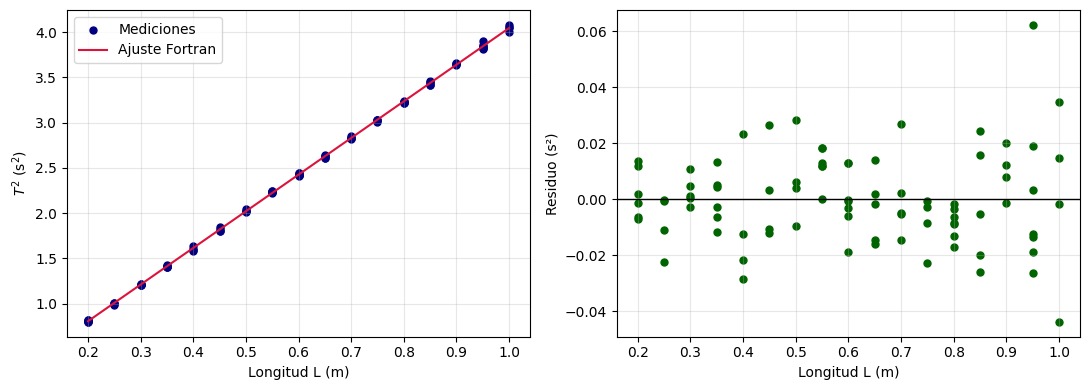

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Lee las cinco columnas producidas por el script de limpieza
datos = np.loadtxt("pendulo_limpio.dat")
longitud_m = datos[:, 1] / 100.0
numero_oscilaciones = datos[:, 3]
tiempo_total_s = datos[:, 4]

# Construya las variables linealizadas x=L y y=T^2
periodo_s = tiempo_total_s / numero_oscilaciones
x = longitud_m
y = periodo_s**2

# Parámetros calculados por el programa Fortran
a = 4.0494334936484542
b = -0.0031597771405320252

# Ordena x para dibujar una línea continua de izquierda a derecha
orden = np.argsort(x)
y_ajustada = a*x + b
residuos = y - y_ajustada

# Primer panel: mediciones y recta. Segundo panel: residuos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.scatter(x, y, s=25, color="navy", label="Mediciones")
ax1.plot(x[orden], y_ajustada[orden],
         color="crimson", label="Ajuste Fortran")

ax1.set_xlabel("Longitud L (m)")
ax1.set_ylabel(r"$T^2$ (s$^2$)")
ax1.grid(alpha=0.3)
ax1.legend()

ax2.axhline(0.0, color="black", linewidth=1)
ax2.scatter(x, residuos, s=25, color="darkgreen")

ax2.set_xlabel("Longitud L (m)")
ax2.set_ylabel("Residuo (s²)")
ax2.grid(alpha=0.3)

plt.tight_layout()

# Guarda la figura que se entregará con el informe
plt.savefig("ajuste_pendulo_y_residuos.png",
            dpi=200, bbox_inches="tight")

plt.show()

In [26]:
from google.colab import files

files.download("ajuste_pendulo_y_residuos.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Parte D**

Prueba de PASS/FAIL

In [27]:
from pathlib import Path
import numpy as np

# Función auxiliar que imprime un veredicto uniforme para cada prueba
resultados_pruebas = []

def informar(nombre, condicion, detalle=""):
    estado = "PASS" if condicion else "FAIL"
    print(f"{estado:<4}  {nombre}{detalle}")
    resultados_pruebas.append(bool(condicion))
    return bool(condicion)

# Archivos que debe producir el flujo de trabajo completo
archivo_datos = Path("pendulo_limpio.dat")
archivo_resultados = Path("resultados_ajuste.dat")
archivo_figura = Path("ajuste_pendulo_y_residuos.png")

# Primer nivel: comprueba existencia antes de intentar leer
ok_datos = informar("Existe pendulo_limpio.dat", archivo_datos.exists())
ok_resultados = informar("Existe resultados_ajuste.dat", archivo_resultados.exists())
informar("Existe la figura", archivo_figura.exists() and archivo_figura.stat().st_size > 0 if archivo_figura.exists() else False)

# Segundo nivel: valida formatos y compara con un cálculo independiente
if ok_datos and ok_resultados:
    try:
        datos = np.atleast_2d(np.loadtxt(archivo_datos))
        resultados = np.loadtxt(archivo_resultados).reshape(-1)

        estructura_datos = datos.shape[1] == 5 and datos.shape[0] >= 2
        estructura_resultados = resultados.size == 5
        informar("Formato del archivo de datos", estructura_datos, f"  filas={datos.shape[0]}, columnas={datos.shape[1]}")
        informar("Formato del archivo de resultados", estructura_resultados, f"  valores={resultados.size}")

        if estructura_datos and estructura_resultados:
            # Reconstruye x=L y y=T^2 directamente desde los datos limpios
            longitud_m = datos[:, 1] / 100.0
            periodo_s = datos[:, 4] / datos[:, 3]
            x = longitud_m
            y = periodo_s**2
            n_ref = len(x)

            # Calcula los valores de referencia con las fórmulas del método
            sx = np.sum(x)
            sy = np.sum(y)
            sxx = np.sum(x*x)
            sxy = np.sum(x*y)
            den = n_ref*sxx - sx*sx
            a_ref = (n_ref*sxy - sx*sy) / den
            b_ref = (sy - a_ref*sx) / n_ref
            residuos_ref = y - (a_ref*x + b_ref)
            sse_ref = np.sum(residuos_ref**2)
            sst_ref = np.sum((y - np.mean(y))**2)
            r2_ref = 1.0 - sse_ref/sst_ref
            g_ref = 4.0*np.pi**2/a_ref

            # Compara, con tolerancia, cada resultado entregado por Fortran
            n_f, a_f, b_f, r2_f, g_f = resultados
            informar("Número de datos N", int(round(n_f)) == n_ref, f"  obtenido={n_f:g}, esperado={n_ref}")
            informar("Pendiente a", np.isclose(a_f, a_ref, rtol=1e-6, atol=1e-9), f"  obtenida={a_f:.8g}, esperada={a_ref:.8g}")
            informar("Intercepto b", np.isclose(b_f, b_ref, rtol=1e-6, atol=1e-9), f"  obtenido={b_f:.8g}, esperado={b_ref:.8g}")
            informar("Coeficiente R²", np.isclose(r2_f, r2_ref, rtol=1e-6, atol=1e-9), f"  obtenido={r2_f:.8g}, esperado={r2_ref:.8g}")
            informar("Gravedad g", np.isclose(g_f, g_ref, rtol=1e-6, atol=1e-9), f"  obtenida={g_f:.8g}, esperada={g_ref:.8g}")
            informar("Valor físico razonable de g", 7.0 < g_f < 12.0, f"  g={g_f:.5f} m/s²")
    except Exception as error:
        informar("No fue posible completar la verificación", False, f": {error}")

# Resumen que debe copiarse en el informe de una página
n_pass = sum(resultados_pruebas)
n_total = len(resultados_pruebas)
print(f"\nRESUMEN PASS/FAIL: {n_pass} de {n_total} pruebas pasaron.")

PASS  Existe pendulo_limpio.dat
PASS  Existe resultados_ajuste.dat
PASS  Existe la figura
PASS  Formato del archivo de datos  filas=87, columnas=5
PASS  Formato del archivo de resultados  valores=5
PASS  Número de datos N  obtenido=87, esperado=87
PASS  Pendiente a  obtenida=4.0494335, esperada=4.0494335
PASS  Intercepto b  obtenido=-0.0031597771, esperado=-0.0031597771
PASS  Coeficiente R²  obtenido=0.99974198, esperado=0.99974198
PASS  Gravedad g  obtenida=9.7491211, esperada=9.7491211
PASS  Valor físico razonable de g  g=9.74912 m/s²

RESUMEN PASS/FAIL: 11 de 11 pruebas pasaron.




> Añadir blockquote

